In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import scipy
import seaborn as sns

In [56]:
# loading the data
combined = pd.read_csv("datas1.csv")
combined.head()

,Replicate,Treatment,Speed
0,1,Control,43.69202
1,1,Control,41.85664
2,1,Control,49.11707
3,1,Control,49.79331
4,1,Control,41.54301


In [57]:
# getting in right format
ReplicateAverages = combined.groupby(["Treatment","Replicate"], as_index=False).agg({"Speed":"mean"})
ReplicateAvePivot = ReplicateAverages.pivot_table(columns="Treatment", values="Speed", index="Replicate")
ReplicateAvePivot.head(10)

Treatment,Control,Drug
Replicate,,
1,41.490610,29.573912
2,32.638003,22.317653
3,20.622035,12.898156


In [66]:
# statistics
statistic, pvalue = scipy.stats.ttest_rel(ReplicateAvePivot["Control"], ReplicateAvePivot["Drug"])
print("pvalue:", pvalue, "\n" "& t-statistic:", statistic)

mean = ReplicateAvePivot.mean()
print(mean)
sem = ReplicateAvePivot.sem()
print(sem)

pvalue: 0.01463875293852146 
& t-statistic: 8.174075882056934
Treatment
Control    31.583549
Drug       21.596574
dtype: float64
Treatment
Control    6.047266
Drug       4.827359
dtype: float64


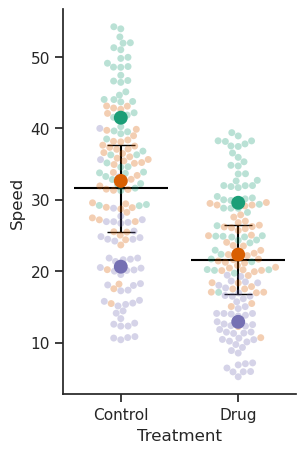

In [76]:
# plotting

# Create a Figure object
fig, ax = plt.subplots(figsize=(3, 5))

sns.despine()

# Swarm plot for individual data points
sns.swarmplot(x="Treatment", y="Speed", hue="Replicate", alpha=0.3, palette="Dark2", data=combined, ax=ax)

# Swarm plot for replicate averages
ax = sns.swarmplot(x="Treatment", y="Speed", hue="Replicate", size=10, palette="Dark2", data=ReplicateAverages, ax=ax)

# line as mean
for i, m in enumerate(mean):
    plt.hlines(m, i - 0.4, i + 0.4, color='black', linewidth=1.5)

# rest of error bar
plt.errorbar(range(len(mean)), mean, yerr = sem, capsize = 10, color='black', alpha=1,
             linewidth=1.5, linestyle='', marker='_')

# Remove legend
ax.legend_.remove()

# exporting the graph
plt.savefig("seaborn_plot.png", dpi = 300)    

plt.show()

In [74]:
cmap = sns.choose_colorbrewer_palette("q")

interactive(children=(Dropdown(description='name', options=('Set1', 'Set2', 'Set3', 'Paired', 'Accent', 'Paste…